# **실습 1: Logistic Regression**

-  Kaggle 'Smartphone_Usage_And_Addiction_Analysis' 데이터를 사용한 실습
-  이진 분류 문제 (binary classification problem) - Addicted or Not Addicted

- 주요 Packages
   - Pandas: table형 데이터를 다룸
   - Scikit-learn: 머신러닝에서 사용되는 많은 알고리즘을 지원 함
   - Matplotlib : matlab이라는 공학툴의 Graph 그리기기능을 구현
   - seaborn : 데이터 시각화 툴
   - numpy: 다차원 배열의 수치해석을 지원하는 Python의 대표적인 numerical 처리 인프라 패키지 

Note 1: Kaggle에 공개된 내용을 강의에 맞도록 정리하고 한글화하였음

Note 2: 본강의는 DL 라이브러리로 Pytorch를 사용할 것이므로, Keras 를 이용한 MLP 처리는 강의에는 포함하지 않음 (비교용으로 남겨둠) 

## 1. 데이터 로딩  

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [3]:
# Reading the data
datafile= r"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"  # 7500명의 데이터 파일
data = pd.read_csv(datafile)  # Pandas 를 사용하여 CSV 파일을 Data-frame (Table) 형태로 읽어들임
data.head()  # 면앞의 몇개의 데이터를 화면에 출력하여 확인할 수 있도록 함 

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
data.shape  # Table의 column 과 row 수를 확인함.

(7500, 16)

## 2. 사전 데이터 분석 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

*'addicted_label' is the target variable with values 0 and 1 classifying a user to be addicted or not addicted to smartphones*

In [6]:
data['addicted_label'].unique()

array([0, 1])

In [7]:
data['addiction_level'].unique()

array([nan, 'Mild', 'Moderate', 'Severe'], dtype=object)

In [8]:
data['stress_level'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [5]:
!pip install seaborn # 데이터 시각화 패키지 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


addicted_label
1    5308
0    2192
Name: count, dtype: int64

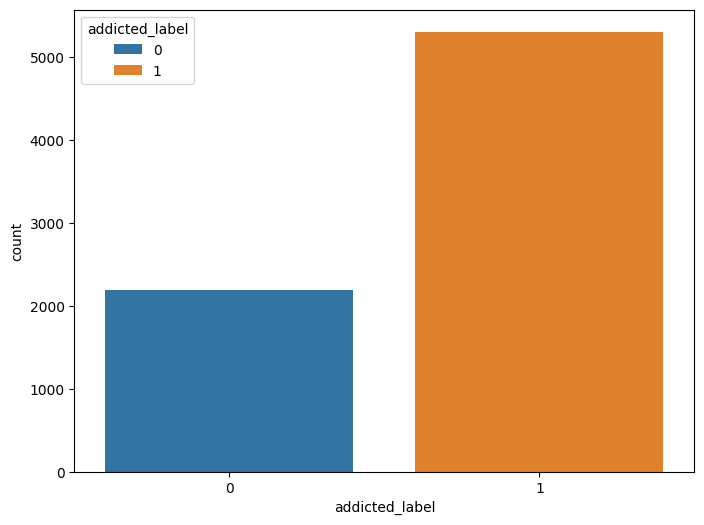

In [10]:
#import the required libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(
    data=data,
    x='addicted_label',
    hue='addicted_label',
)
data['addicted_label'].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64

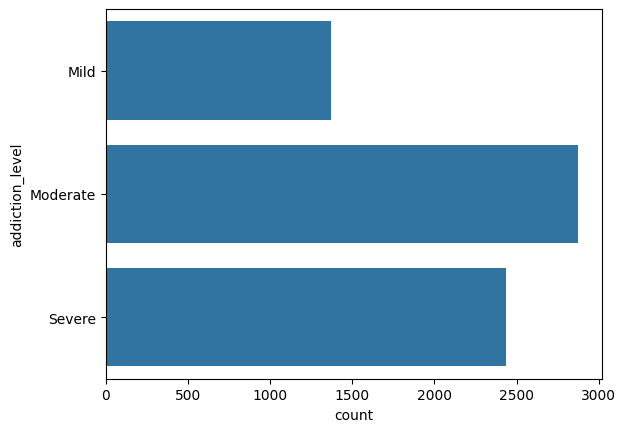

In [12]:
sns.countplot(data['addiction_level'],label="Count")
data['addiction_level'].value_counts()

stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64

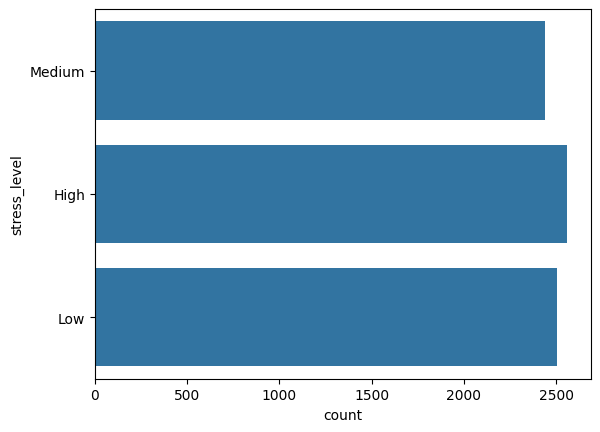

In [13]:
sns.countplot(data['stress_level'],label="Count")
data['stress_level'].value_counts()

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

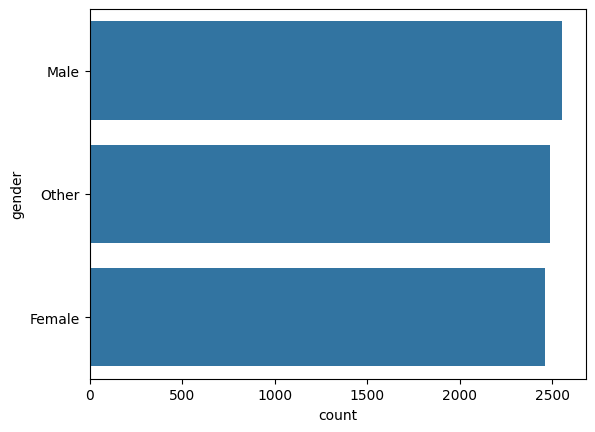

In [14]:
sns.countplot(data['gender'],label="Count")
data['gender'].value_counts()

<Axes: xlabel='stress_level', ylabel='addicted_label'>

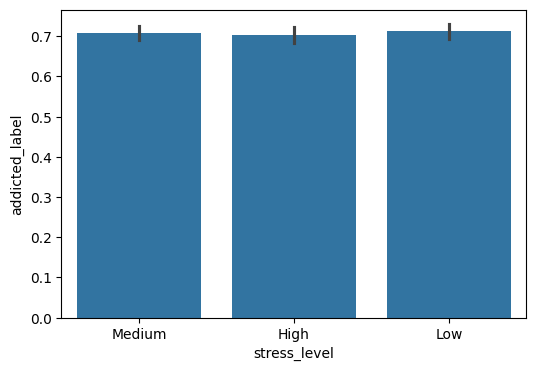

In [15]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=data,
    x='stress_level',
    y='addicted_label'
)

In [16]:
#Average stats
print("Average daily screen time ", data['daily_screen_time_hours'].mean())
print("Average social_media_hours ", data['social_media_hours'].mean())
print("Average weekend_screen_time", data['weekend_screen_time'].mean())
print("Average gaming_hours", data['gaming_hours'].mean())
print("Average sleep_hours", data['sleep_hours'].mean())

Average daily screen time  7.499911999999999
Average social_media_hours  3.273484
Average weekend_screen_time 9.243826666666669
Average gaming_hours 2.0141826666666667
Average sleep_hours 6.737561333333333


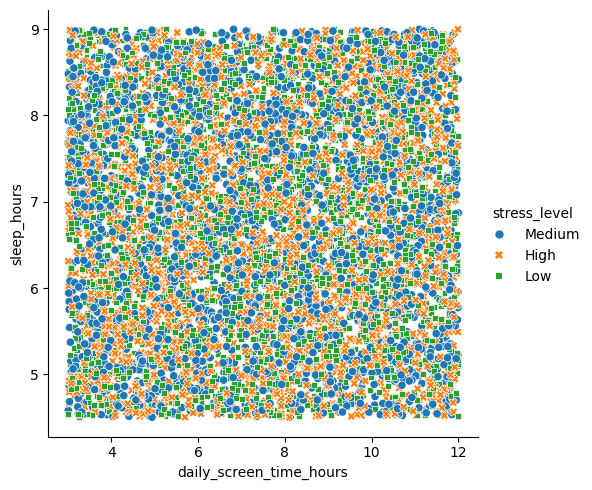

In [17]:
sns.relplot(data = data, x="daily_screen_time_hours",y="sleep_hours",hue="stress_level",style="stress_level")

<Axes: xlabel='daily_screen_time_hours', ylabel='Density'>

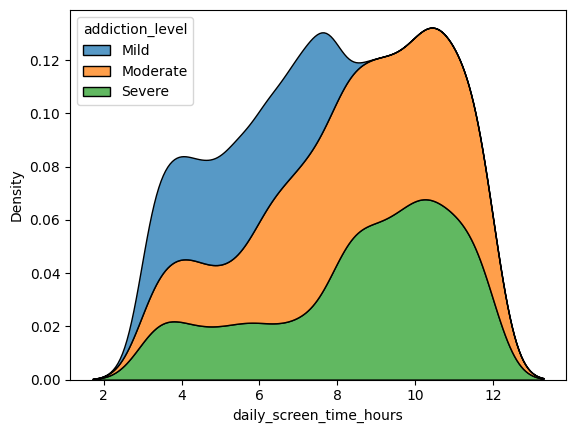

In [18]:
sns.kdeplot(data=data, x="daily_screen_time_hours", hue="addiction_level", multiple="stack")

<Axes: xlabel='social_media_hours', ylabel='Density'>

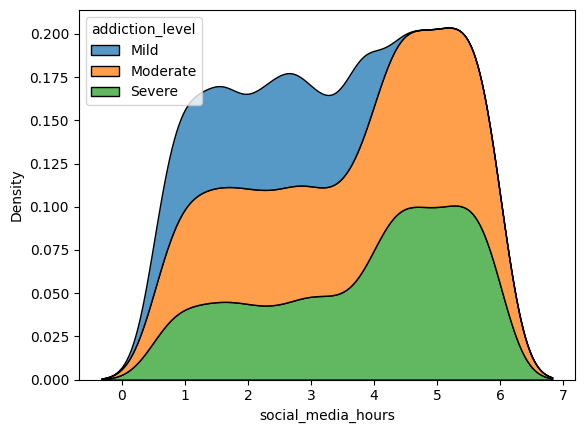

In [19]:
sns.kdeplot(data=data, x="social_media_hours", hue="addiction_level", multiple="stack")

<Axes: xlabel='weekend_screen_time', ylabel='Density'>

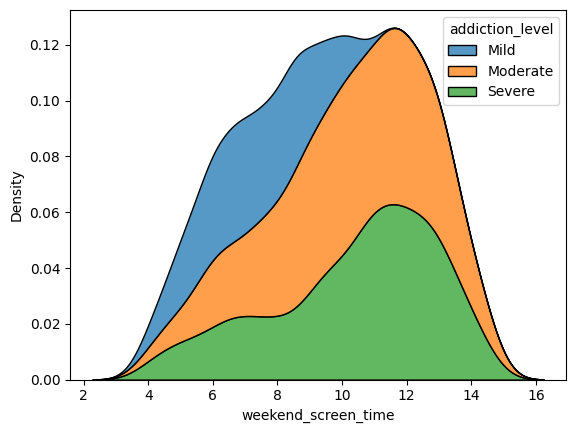

In [20]:
sns.kdeplot(data=data, x="weekend_screen_time", hue="addiction_level", multiple="stack")

### 상관도분석 




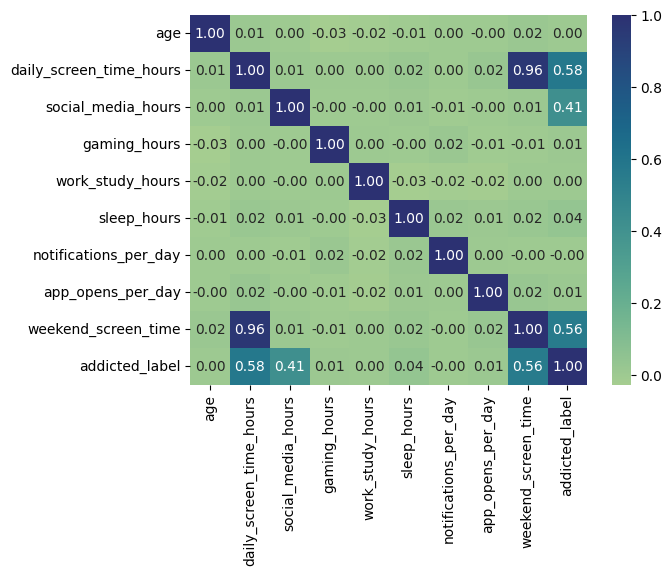

In [11]:
corr = data.corr(numeric_only=True)  # 숫자로 된 데이터만을 사용 
sns.heatmap(corr, annot=True, cmap='crest', fmt=".2f")
plt.show()

#### 관찰 결과 
  - 'daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time' 등은 'addicted_label' 과 상관도가 높고 나머지는 그렇지 않음
  - 따라서 분석시에 상관도가 높은 3 개만을을 사용함.
    

# 3. Logistic Regression model

In [29]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 34.5 MB/s  0:00:009.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [12]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3)  # 7:3으로 데이터를 training 과 test 용으로 나눔

train_X_data = train[['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time']].copy()
test_X_data = test[['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time']].copy()
train_Y_data = train[['addicted_label']].copy()
test_Y_data = test[['addicted_label']].copy()
print(train_X_data.shape, train_Y_data.shape)
print(test_X_data.shape, test_Y_data.shape)

(5250, 3) (5250, 1)
(2250, 3) (2250, 1)


In [13]:
#Normalizing the data (매우중요함) 
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the data
normalized_training_data = scaler.fit_transform(train_X_data)
normalized_testing_data = scaler.fit_transform(test_X_data) 

### training 

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(train_X_data, train_Y_data)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### test

In [16]:
logistic_regression_model.score(test_X_data, test_Y_data) # test on test data 

0.8951111111111111

In [17]:
y_pred = logistic_regression_model.predict(test_X_data)

# Get the classification report as a string
report_string = classification_report(test_Y_data, y_pred, target_names=['addicted','not addicted'])
print(report_string)

              precision    recall  f1-score   support

    addicted       0.83      0.80      0.82       653
not addicted       0.92      0.93      0.93      1597

    accuracy                           0.90      2250
   macro avg       0.88      0.87      0.87      2250
weighted avg       0.89      0.90      0.89      2250



# Artificial Neural Network

Note: 원저자의 ANN 코드. Tensorflow (KERAS) 기반이라 강의하지는 않음. 동일한 내용을 PyTorch 로 구현한 것을 대신 사용함

In [21]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers

'''
EPOCHS = 300
HIDDEN_UNITS = 128
BATCH_SIZE = 512
'''

EPOCHS = 300
HIDDEN_UNITS = 32
BATCH_SIZE = 16


VERBOSE = 1
HIDDEN_LAYER_ACTIVATION = 'relu'
OUTPUT_LAYER_ACTIVATION = 'sigmoid'

model = Sequential()
model.add(Dense(HIDDEN_UNITS, input_dim=3, activation=HIDDEN_LAYER_ACTIVATION))
model.add(Dense(HIDDEN_UNITS, activation=HIDDEN_LAYER_ACTIVATION))
model.add(Dense(1, activation=OUTPUT_LAYER_ACTIVATION))

model.compile(loss='binary_crossentropy',optimizer='SGD', metrics=['acc'])

In [ ]:
# Training the model.
model.fit(train_X_data, train_Y_data,
               epochs=EPOCHS,
               verbose=VERBOSE, batch_size= BATCH_SIZE)

Epoch 1/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.6835 - loss: 0.5441
Epoch 2/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - acc: 0.7724 - loss: 0.4197
Epoch 3/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step - acc: 0.8329 - loss: 0.3626
Epoch 4/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - acc: 0.8499 - loss: 0.3234
Epoch 5/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - acc: 0.8756 - loss: 0.2889
Epoch 6/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - acc: 0.8874 - loss: 0.2578
Epoch 7/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - acc: 0.8888 - loss: 0.2552
Epoch 8/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - acc: 0.9002 - loss: 0.2355
Epoch 9/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - acc: 0.9062 - loss: 0.2209
Epoch 10/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 382us/step - acc: 0.9067 - loss: 0.2188
Epoch 11/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step - acc: 0.9124 - loss: 0.1993
Epoch 12/300
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - acc: 0.9151 - loss

In [20]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_X_data, test_Y_data)
print('Test accuracy:', test_acc)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8824 - loss: 0.2854
Test accuracy: 0.8955555558204651


In [27]:
y_pred = (model.predict(test_X_data) > 0.5).astype("int32")

# Get the classification report as a string
report_string = classification_report(test_Y_data, y_pred, target_names=['addicted','not addicted'])
print(report_string)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    addicted       0.90      0.80      0.85       670
not addicted       0.92      0.96      0.94      1580

    accuracy                           0.91      2250
   macro avg       0.91      0.88      0.89      2250
weighted avg       0.91      0.91      0.91      2250



# 결론 

- Logistic Regression 은 MLP의 특별한 경우로 생각할 수 있음
     - 출력 노드 1 neuron,  중간 레이어 없음, Activation은 Sigmoid 함수
 
- 이 데이터셋의 경우 ANN이 성능이 Logistic Regression에 비하여 월등히 높다고 볼 수는 없음 (물론, 이 정도면 논문에서는 높다고 주장하고 출판이됨)
     - 그 이유는 입력변수들간의 상호작용이 많지 않기 때문이라고 보임.
     - 즉, 어떤 두개, 세꼐의 요소가 복합적인 패턴을 만족하였을 때 중독에 영향을 준것이 아니라, 각각이 일정한 비율로 영향을 주었기 때문이라고 해석됨
     - 따라서 Logistic regression으로 충분히 원하는 결과를 얻는 경우, 궂이 복잡한 NN을 이용하는 것은 실제적으로 의미가 없다는 판단.
       